In [1]:
# -*- coding: utf-8 -*-
"""Model-3-RF.ipynb
Ensemble of Texture-Only ResNet50 Image Model + Random Forest (10 trees, depth 3)
for leaf classification. Random Forest is pre-trained on numerical features (Length, Width),
then its class probabilities are blended with the image model's softmax outputs at inference.
"""

# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Create workspace
!mkdir -p /content/ensemble_leaf_classification
!mkdir -p /content/ensemble_leaf_classification/checkpoints
!mkdir -p /content/ensemble_leaf_classification/logs

import os
os.chdir('/content/ensemble_leaf_classification')

print("✓ Workspace created")

Mounted at /content/drive
✓ Workspace created


In [2]:
# ============================================
# CELL 2: Install Dependencies
# ============================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless pillow numpy pandas scikit-learn tqdm matplotlib seaborn gspread google-auth

print("✓ All packages installed")


✓ All packages installed


In [3]:
# ============================================
# CELL 3: Configuration
# ============================================
import torch
import numpy as np
import random

class Config:
    # Paths
    IMAGE_DATASET_PATH = "/content/drive/MyDrive/Refine_Dataset"  # CHANGE THIS

    # Model parameters
    NUM_CLASSES = 30
    INPUT_SIZE = 224
    BATCH_SIZE = 64
    NUM_EPOCHS_IMAGE = 110
    LEARNING_RATE_IMAGE = 0.001

    # Numerical model parameters
    NUMERICAL_FEATURES = 2  # Length and Width

    # Random Forest parameters  ← CHANGED from MLP hidden layers
    RF_N_ESTIMATORS = 30
    RF_MAX_DEPTH = 5

    # Ensemble parameters
    IMAGE_WEIGHT = 0.5
    NUMERICAL_WEIGHT = 0.5

    # Training
    NUM_WORKERS = 2
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

    # Checkpointing
    SAVE_DIR = "/content/ensemble_leaf_classification/checkpoints"

    def __init__(self):
        assert abs(self.IMAGE_WEIGHT + self.NUMERICAL_WEIGHT - 1.0) < 1e-6, \
            "Weights must sum to 1"

config = Config()

random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)

print(f"✓ Configuration loaded")
print(f"✓ Device: {config.DEVICE}")
print(f"✓ RF: {config.RF_N_ESTIMATORS} trees, max_depth={config.RF_MAX_DEPTH}")
print(f"✓ Ensemble weights: Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}")

✓ Configuration loaded
✓ Device: cuda
✓ RF: 30 trees, max_depth=5
✓ Ensemble weights: Image=0.5, Numerical=0.5


In [4]:
# ============================================
# CELL 4: Load Numerical Data
# ============================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.model_selection import train_test_split

def load_numerical_data_from_csv():
    """Load length and width data (100 rows per species)"""

    print("📁 Please upload your leaf_measurements.csv file")
    print("With columns: Class, Length, Width")

    uploaded = files.upload()

    for filename in uploaded.keys():
        df = pd.read_csv(filename)
        print(f"✓ Loaded {filename}")
        print(f"   Total rows: {len(df)}")
        break

    required_columns = ['Class', 'Length', 'Width']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    rows_per_class = df.groupby('Class').size()
    print(f"\n📊 Rows per species:")
    for species, count in rows_per_class.items():
        print(f"   {species}: {count} rows")

    class_names   = df['Class'].values
    lengths       = df['Length'].astype(float).values
    widths        = df['Width'].astype(float).values

    numerical_features = np.column_stack([lengths, widths])

    unique_classes = df['Class'].unique()
    class_to_idx   = {cls: idx for idx, cls in enumerate(unique_classes)}
    labels         = np.array([class_to_idx[cls] for cls in class_names])

    scaler = StandardScaler()
    numerical_features_scaled = scaler.fit_transform(numerical_features)

    print(f"\n✓ Numerical data loaded:")
    print(f"   Total samples:       {len(numerical_features_scaled)}")
    print(f"   Number of species:   {len(unique_classes)}")
    print(f"   Features per sample: {numerical_features_scaled.shape[1]} (Length, Width)")
    print(f"   Labels shape:        {labels.shape}")
    print(f"\n📊 Feature statistics (original scale):")
    print(f"   Length - Mean: {lengths.mean():.2f}cm, Std: {lengths.std():.2f}cm")
    print(f"   Width  - Mean: {widths.mean():.2f}cm, Std: {widths.std():.2f}cm")

    return numerical_features_scaled, labels, class_to_idx, scaler, df

# Load data
numerical_features, numerical_labels, class_to_idx, scaler, df = load_numerical_data_from_csv()

print(f"\n✓ Class mapping created for {len(class_to_idx)} species")
print(f"   Example mapping: {list(class_to_idx.items())[:5]}")


📁 Please upload your leaf_measurements.csv file
With columns: Class, Length, Width


Saving MMPD-30_morphological_matric.csv to MMPD-30_morphological_matric.csv
✓ Loaded MMPD-30_morphological_matric.csv
   Total rows: 300

📊 Rows per species:
   1.Tulshi: 10 rows
   10.Jolpai: 10 rows
   11.Neem: 10 rows
   12.Joba: 10 rows
   13.Telakucha: 10 rows
   14.Noyontara: 10 rows
   15.Bongada: 10 rows
   16.Boroi: 10 rows
   17.Horitoki: 10 rows
   18.Mehedi: 10 rows
   19.Aorhor: 10 rows
   2.Pathorkuchi: 10 rows
   20.Pudina: 10 rows
   21.Thankuni: 10 rows
   22.Paharipata: 10 rows
   23.Lemon: 10 rows
   24.Dhutra: 10 rows
   25.Raktapata: 10 rows
   26.Akondo: 10 rows
   27.Karipata: 10 rows
   28.Oporajita: 10 rows
   29.Hasnahena: 10 rows
   3.Bashok: 10 rows
   30.Orjun: 10 rows
   4.Hatishur: 10 rows
   5.Goolmorich: 10 rows
   6.Togor: 10 rows
   7.Daruchini: 10 rows
   8.Tejpata: 10 rows
   9.Sofeda: 10 rows

✓ Numerical data loaded:
   Total samples:       300
   Number of species:   30
   Features per sample: 2 (Length, Width)
   Labels shape:        (300,)

📊 F

In [5]:
# ============================================
# CELL 5: Image Dataset with Matching Numerical Features
# ============================================
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

class LeafDatasetWithNumerical(Dataset):
    """Dataset that matches each image with its corresponding numerical features"""

    def __init__(self, root_dir, numerical_df, class_to_idx, is_train=True):
        self.root_dir      = root_dir
        self.numerical_df  = numerical_df
        self.class_to_idx  = class_to_idx
        self.is_train      = is_train
        self.idx_to_class  = {v: k for k, v in class_to_idx.items()}
        self.samples       = []
        self._load_samples()

        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(config.INPUT_SIZE, scale=(0.6, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(20),
                transforms.ColorJitter(brightness=0.2, contrast=0.3),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])

    def _load_samples(self):
        class_folders = [d for d in os.listdir(self.root_dir)
                         if os.path.isdir(os.path.join(self.root_dir, d))]

        for class_name in class_folders:
            if class_name not in self.class_to_idx:
                print(f"⚠️  Warning: {class_name} not in numerical data, skipping")
                continue

            class_idx  = self.class_to_idx[class_name]
            class_path = os.path.join(self.root_dir, class_name)

            class_numerical_data = self.numerical_df[
                self.numerical_df['Class'] == class_name
            ]

            images = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            print(f"   {class_name}: {len(images)} images, "
                  f"{len(class_numerical_data)} numerical samples")

            for img_idx, img_file in enumerate(images):
                img_path = os.path.join(class_path, img_file)

                numerical_idx    = img_idx % len(class_numerical_data)
                numerical_sample = class_numerical_data.iloc[numerical_idx]

                num_feats = np.array([
                    numerical_sample['Length'],
                    numerical_sample['Width']
                ], dtype=np.float32)

                self.samples.append({
                    'image_path':        img_path,
                    'label':             class_idx,
                    'numerical_features': num_feats
                })

        print(f"\n✓ Loaded {len(self.samples)} image-numerical pairs")
        labels_count = pd.Series([s['label'] for s in self.samples]).value_counts()
        print(f"   Samples per class: {dict(sorted(labels_count.items()))}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image  = Image.open(sample['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        num_feat = torch.tensor(sample['numerical_features'], dtype=torch.float32)
        return image, num_feat, sample['label']


def create_dataloaders():
    """Create train, validation, and test dataloaders"""
    train_path = os.path.join(config.IMAGE_DATASET_PATH, 'train')
    val_path   = os.path.join(config.IMAGE_DATASET_PATH, 'val')
    test_path  = os.path.join(config.IMAGE_DATASET_PATH, 'test')

    if os.path.exists(train_path) and os.path.exists(val_path):
        print("📁 Using existing train/val/test split")
        train_dataset = LeafDatasetWithNumerical(train_path, df, class_to_idx, is_train=True)
        val_dataset   = LeafDatasetWithNumerical(val_path,   df, class_to_idx, is_train=False)
        test_dataset  = LeafDatasetWithNumerical(test_path,  df, class_to_idx, is_train=False)
    else:
        print("📁 Creating train/val/test split (60/25/15)")
        full_dataset = LeafDatasetWithNumerical(
            config.IMAGE_DATASET_PATH, df, class_to_idx, is_train=True
        )
        total_size = len(full_dataset)
        train_size = int(0.6 * total_size)
        val_size   = int(0.25 * total_size)
        test_size  = total_size - train_size - val_size
        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size, test_size]
        )
        print(f"   Train: {train_size}, Val: {val_size}, Test: {test_size}")

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                              shuffle=True,  num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=config.BATCH_SIZE,
                              shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=config.BATCH_SIZE,
                              shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)

    return train_loader, val_loader, test_loader

print("\n📊 Creating dataloaders...")
train_loader, val_loader, test_loader = create_dataloaders()



📊 Creating dataloaders...
📁 Creating train/val/test split (60/25/15)
   9.Sofeda: 100 images, 10 numerical samples
   7.Daruchini: 100 images, 10 numerical samples
   8.Tejpata: 100 images, 10 numerical samples
   5.Goolmorich: 100 images, 10 numerical samples
   4.Hatishur: 100 images, 10 numerical samples
   6.Togor: 100 images, 10 numerical samples
   30.Orjun: 100 images, 10 numerical samples
   3.Bashok: 100 images, 10 numerical samples
   29.Hasnahena: 100 images, 10 numerical samples
   26.Akondo: 100 images, 10 numerical samples
   27.Karipata: 100 images, 10 numerical samples
   28.Oporajita: 100 images, 10 numerical samples
   25.Raktapata: 100 images, 10 numerical samples
   23.Lemon: 100 images, 10 numerical samples
   24.Dhutra: 100 images, 10 numerical samples
   22.Paharipata: 100 images, 10 numerical samples
   21.Thankuni: 100 images, 10 numerical samples
   19.Aorhor: 100 images, 10 numerical samples
   18.Mehedi: 100 images, 10 numerical samples
   20.Pudina: 100 im

In [9]:
test_loader
first_batch = next(iter(test_loader))

In [18]:
# Unpack the first batch
features, numeric, labels = first_batch
# 1. Check the overall dimensions of the batch
print("Features shape:", features.shape)
print("Numeric shape:", numeric.shape)
print("Labels shape:", labels.shape)

# 2. Check the data types of the tensors
print("Features data type:", features.dtype)
print("Numeric data type:", numeric.dtype)
print("Labels data type:", labels.dtype)


Features shape: torch.Size([64, 3, 224, 224])
Numeric shape: torch.Size([64, 2])
Labels shape: torch.Size([64])
Features data type: torch.float32
Numeric data type: torch.float32
Labels data type: torch.int64


In [ ]:
import matplotlib.pyplot as plt

for i in range(len(numeric)):
    print(f"\n{numeric[i][0]},{numeric[i][1]},{labels[i]}")

In [ ]:
for i in range(len(numeric)):
    first_image_tensor = features[i]
    img_min = first_image_tensor.min()
    img_max = first_image_tensor.max()
    raw_visual_tensor = (first_image_tensor - img_min) / (img_max - img_min)
    numpy_image = raw_visual_tensor.permute(1, 2, 0).detach().cpu().numpy()
    plt.imshow(numpy_image)
    plt.axis("off")
    plt.show()
    print(f"\n Data {i}:Numeric: {numeric[i]}, Label: {labels[i]}")

In [26]:
# ============================================
# CELL 6: Texture-Only Image Model (ResNet50 Layers 1 & 2)
# ============================================
import torch.nn as nn
import torchvision.models as models

class TextureOnlyImageModel(nn.Module):
    """ResNet50 using only layers 1 & 2 for texture features"""

    def __init__(self, num_classes=30):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.texture_features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, num_classes)  # 512 channels from layer2

    def forward(self, x):
        features = self.texture_features(x)
        pooled   = self.pool(features)
        flat     = pooled.flatten(1)
        return self.classifier(flat)

image_model = TextureOnlyImageModel(num_classes=config.NUM_CLASSES).to(config.DEVICE)
print("✓ Texture-Only Image Model Ready")
print(f"   Total parameters: {sum(p.numel() for p in image_model.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


✓ Texture-Only Image Model Ready
   Total parameters: 1,460,318


In [27]:
# ============================================
# CELL 7: Numerical Model — Random Forest (10 trees, depth 3)
# ============================================
# KEY DESIGN:
#   Random Forest is a sklearn model — it lives on CPU and has no PyTorch graph.
#   Strategy:
#     1. Pre-train the RF on the full numerical dataset BEFORE the ensemble loop.
#     2. During forward(), move numerical features to CPU, call predict_proba(),
#        and convert the resulting probability array back to a GPU tensor so it
#        can be blended with the image logits on the same device.

from sklearn.ensemble import RandomForestClassifier

class NumericalRandomForest:
    """
    Thin wrapper around sklearn RandomForestClassifier that mirrors the
    interface expected by EnsembleModel.
    """

    def __init__(self, n_estimators=20, max_depth=5, num_classes=30):
        self.num_classes = num_classes
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=config.SEED,
            n_jobs=-1          # use all CPU cores during training
        )
        self.is_fitted = False

    def fit(self, X, y):
        """Train on numpy arrays X (N, features) and y (N,)."""
        print(f"\n🌲 Training Random Forest: "
              f"{config.RF_N_ESTIMATORS} trees, max_depth={config.RF_MAX_DEPTH} ...")
        self.model.fit(X, y)
        self.is_fitted = True
        train_acc = (self.model.predict(X) == y).mean() * 100
        print(f"✓ RF training accuracy (full set): {train_acc:.2f}%")

    def predict_proba_tensor(self, numerical_feats_tensor, device):
        """
        Accept a GPU/CPU torch tensor, return a float32 tensor on `device`
        with shape (N, num_classes).

        RF.predict_proba() returns probabilities only for classes seen during
        training. If some class indices are absent (shouldn't happen, but
        guard anyway), we build a full (N, num_classes) matrix.
        """
        if not self.is_fitted:
            raise RuntimeError("Random Forest has not been fitted yet. "
                               "Call rf_model.fit(X_train, y_train) first.")

        X_np = numerical_feats_tensor.detach().cpu().numpy()
        proba_np = self.model.predict_proba(X_np)  # shape: (N, n_seen_classes)

        # Map to full class dimension in case not all classes appeared in a batch
        n_samples = X_np.shape[0]
        full_proba = np.zeros((n_samples, self.num_classes), dtype=np.float32)
        for local_idx, global_class in enumerate(self.model.classes_):
            full_proba[:, global_class] = proba_np[:, local_idx]

        return torch.tensor(full_proba, dtype=torch.float32, device=device)

    def predict(self, X):
        if not self.is_fitted:
            raise RuntimeError("Random Forest has not been fitted yet.")
        return self.model.predict(X)
# ---- Pre-train the RF on the full numerical dataset ----
# We use the complete CSV data (numerical_features + numerical_labels) that was
# loaded in Cell 4.  The RF is sklearn-based, so this is a one-shot .fit() call.

rf_model = NumericalRandomForest(
    n_estimators=config.RF_N_ESTIMATORS,
    max_depth=config.RF_MAX_DEPTH,
    num_classes=config.NUM_CLASSES
)
rf_model.fit(numerical_features, numerical_labels)  # numpy arrays from Cell 4

print("\n✓ Numerical Random Forest Model Ready")
print(f"   Trees:     {config.RF_N_ESTIMATORS}")
print(f"   Max depth: {config.RF_MAX_DEPTH}")


🌲 Training Random Forest: 30 trees, max_depth=5 ...
✓ RF training accuracy (full set): 61.67%

✓ Numerical Random Forest Model Ready
   Trees:     30
   Max depth: 5


In [28]:
# ============================================
# CELL 8: Ensemble Model (Weighted Combination)
# ============================================
class EnsembleModel(nn.Module):
    """
    Ensemble of:
      • TextureOnlyImageModel  (PyTorch, outputs raw logits)
      • NumericalRandomForest  (sklearn, outputs class probabilities)

    The image logits are scaled by image_weight and added to the RF
    probability scores scaled by numerical_weight.  Both vectors have
    the same length (NUM_CLASSES), so the blend is straightforward.
    """

    def __init__(self, image_model, rf_model, image_weight=0.5, numerical_weight=0.5):
        super().__init__()
        self.image_model      = image_model
        self.rf_model         = rf_model        # NOT registered as a submodule (not nn.Module)
        self.image_weight     = image_weight
        self.numerical_weight = numerical_weight

    def forward(self, images, numerical_feats):
        # --- Image branch (runs on GPU if available) ---
        image_logits = self.image_model(images)          # (N, NUM_CLASSES)

        # --- RF branch (CPU → probability tensor → back to device) ---
        rf_proba = self.rf_model.predict_proba_tensor(
            numerical_feats, device=images.device
        )                                                # (N, NUM_CLASSES)

        # Weighted blend
        final_logits = (self.image_weight     * image_logits +
                        self.numerical_weight * rf_proba)
        return final_logits

    def set_weights(self, image_weight, numerical_weight):
        self.image_weight     = image_weight
        self.numerical_weight = numerical_weight
        print(f"✓ Weights updated: Image={image_weight:.2f}, RF={numerical_weight:.2f}")


# NOTE: only the image model (an nn.Module) is moved to the device.
# The RF is sklearn-based and always stays on CPU.
ensemble_model = EnsembleModel(
    image_model      = image_model,
    rf_model         = rf_model,
    image_weight     = config.IMAGE_WEIGHT,
    numerical_weight = config.NUMERICAL_WEIGHT
)
# Move only the PyTorch sub-module to the device
ensemble_model.image_model = ensemble_model.image_model.to(config.DEVICE)

print(f"\n✓ Ensemble Model Ready")
print(f"   Image weight: {config.IMAGE_WEIGHT}")
print(f"   RF weight:    {config.NUMERICAL_WEIGHT}")



✓ Ensemble Model Ready
   Image weight: 0.5
   RF weight:    0.5


🔄 Loading checkpoint...
✓ Resumed from epoch 100

🚀 Training Ensemble Model (Image + RF)
Device:          cuda
Epochs:          110
Image weight:    0.5
RF weight:       0.5
RF trees/depth:  30 / 5



Epoch 101/110 [Val]: 100%|██████████| 12/12 [04:37<00:00, 23.14s/it, loss=0.3843]



📊 Epoch 101/110
   Train - Loss: 0.1295, Acc: 0.9700
   Val   - Loss: 0.2707,   Acc: 0.9160
   Best Val Acc: 0.9453



Epoch 102/110 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.80it/s, loss=0.2679]



📊 Epoch 102/110
   Train - Loss: 0.1360, Acc: 0.9639
   Val   - Loss: 0.1986,   Acc: 0.9307
   Best Val Acc: 0.9453



...


📊 Epoch 108/110
   Train - Loss: 0.1031, Acc: 0.9672
   Val   - Loss: 0.2599,   Acc: 0.9347
   Best Val Acc: 0.9720



Epoch 109/110 [Val]: 100%|██████████| 12/12 [00:06<00:00,  1.98it/s, loss=0.1282]


🎉 New best validation accuracy: 0.9760

📊 Epoch 109/110
   Train - Loss: 0.0762, Acc: 0.9817
   Val   - Loss: 0.0956,   Acc: 0.9760
   Best Val Acc: 0.9760



Epoch 110/110 [Val]: 100%|██████████| 12/12 [00:07<00:00,  1.58it/s, loss=0.1654]


🎉 New best validation accuracy: 0.9787

📊 Epoch 110/110
   Train - Loss: 0.0791, Acc: 0.9850
   Val   - Loss: 0.0849,   Acc: 0.9787
   Best Val Acc: 0.9787



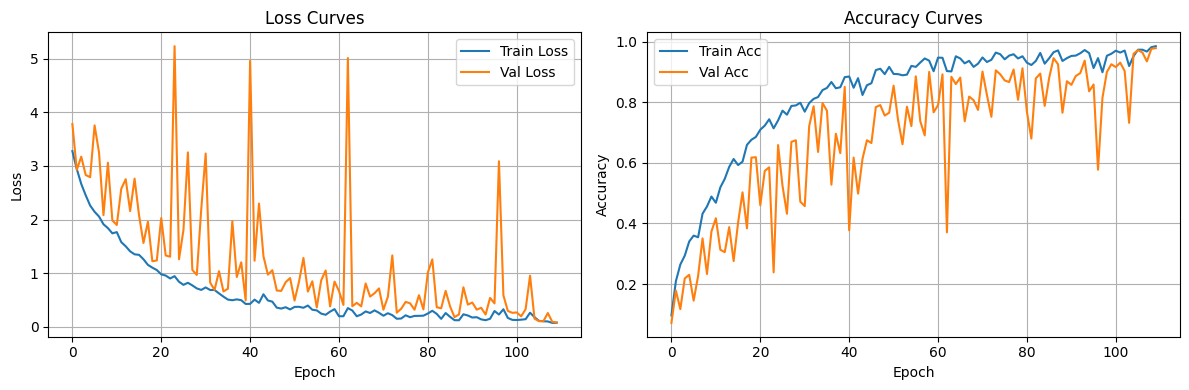


✅ Training Complete!
✓ Best validation accuracy: 0.9787


In [29]:
# ============================================
# CELL 9: Training Functions
# (Only the image model is trained; RF is already fitted above)
# ============================================
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

class EnsembleTrainer:
    """
    Trains only the image model inside the ensemble.
    The RF branch is frozen (pre-trained in Cell 7) and contributes
    fixed probability scores at each forward pass.
    """

    def __init__(self, ensemble_model, train_loader, val_loader):
        self.ensemble     = ensemble_model
        self.train_loader = train_loader
        self.val_loader   = val_loader

        # Only the image model has learnable parameters
        self.optimizer_image = torch.optim.AdamW(
            ensemble_model.image_model.parameters(),
            lr=config.LEARNING_RATE_IMAGE,
            weight_decay=1e-4
        )

        self.criterion = nn.CrossEntropyLoss()

        self.best_val_acc = 0
        self.train_losses = []
        self.val_losses   = []
        self.train_accs   = []
        self.val_accs     = []
        self.start_epoch  = 0

        self.load_checkpoint()

    # ------------------------------------------------------------------ helpers

    def load_checkpoint(self):
        checkpoint_path = os.path.join(config.SAVE_DIR, 'ensemble_checkpoint.pth')
        if os.path.exists(checkpoint_path):
            print("🔄 Loading checkpoint...")
            checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)
            # Load only image model weights (RF is not part of state_dict)
            self.ensemble.image_model.load_state_dict(
                checkpoint['image_model_state_dict']
            )
            self.optimizer_image.load_state_dict(
                checkpoint['optimizer_image_state_dict']
            )
            self.start_epoch  = checkpoint['epoch'] + 1
            self.best_val_acc = checkpoint['best_val_acc']
            self.train_losses = checkpoint.get('train_losses', [])
            self.val_losses   = checkpoint.get('val_losses',   [])
            self.train_accs   = checkpoint.get('train_accs',   [])
            self.val_accs     = checkpoint.get('val_accs',     [])
            print(f"✓ Resumed from epoch {self.start_epoch}")
            return True
        return False

    def save_checkpoint(self, epoch, is_best=False):
        checkpoint = {
            'epoch':                      epoch,
            'image_model_state_dict':     self.ensemble.image_model.state_dict(),
            'optimizer_image_state_dict': self.optimizer_image.state_dict(),
            'best_val_acc':               self.best_val_acc,
            'train_losses':               self.train_losses,
            'val_losses':                 self.val_losses,
            'train_accs':                 self.train_accs,
            'val_accs':                   self.val_accs,
        }
        torch.save(checkpoint, os.path.join(config.SAVE_DIR, 'ensemble_checkpoint.pth'))
        if is_best:
            torch.save(checkpoint, os.path.join(config.SAVE_DIR, 'ensemble_best.pth'))

    # ------------------------------------------------------------------ epoch loops

    def train_epoch(self, epoch):
        self.ensemble.image_model.train()   # only image model in train mode
        total_loss = 0
        all_preds  = []
        all_labels = []

        pbar = tqdm(self.train_loader,
                    desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Train]')
        for images, numerical_feats, labels in pbar:
            images         = images.to(config.DEVICE)
            numerical_feats = numerical_feats.to(config.DEVICE).float()
            labels         = labels.to(config.DEVICE)

            self.optimizer_image.zero_grad()

            # Forward: image (GPU) + RF probabilities (CPU→GPU inside forward)
            outputs = self.ensemble(images, numerical_feats)
            loss    = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer_image.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_acc = (
                accuracy_score(all_labels[-32:], all_preds[-32:])
                if len(all_preds) >= 32 else 0
            )
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'acc':  f'{current_acc:.3f}'})

        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        self.train_losses.append(avg_loss)
        self.train_accs.append(accuracy)
        return avg_loss, accuracy

    def validate(self, epoch):
        self.ensemble.image_model.eval()
        total_loss = 0
        all_preds  = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(self.val_loader,
                        desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Val]')
            for images, numerical_feats, labels in pbar:
                images          = images.to(config.DEVICE)
                numerical_feats = numerical_feats.to(config.DEVICE).float()
                labels          = labels.to(config.DEVICE)

                outputs = self.ensemble(images, numerical_feats)
                loss    = self.criterion(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(self.val_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        self.val_losses.append(avg_loss)
        self.val_accs.append(accuracy)
        return avg_loss, accuracy

    # ------------------------------------------------------------------ main loop

    def train(self):
        print(f"\n{'='*60}")
        print(f"🚀 Training Ensemble Model (Image + RF)")
        print(f"{'='*60}")
        print(f"Device:          {config.DEVICE}")
        print(f"Epochs:          {config.NUM_EPOCHS_IMAGE}")
        print(f"Image weight:    {config.IMAGE_WEIGHT}")
        print(f"RF weight:       {config.NUMERICAL_WEIGHT}")
        print(f"RF trees/depth:  {config.RF_N_ESTIMATORS} / {config.RF_MAX_DEPTH}")
        print(f"{'='*60}\n")

        for epoch in range(self.start_epoch, config.NUM_EPOCHS_IMAGE):
            train_loss, train_acc = self.train_epoch(epoch)
            val_loss,   val_acc   = self.validate(epoch)

            is_best = val_acc > self.best_val_acc
            if is_best:
                self.best_val_acc = val_acc
                print(f"🎉 New best validation accuracy: {val_acc:.4f}")

            self.save_checkpoint(epoch, is_best)

            print(f"\n📊 Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE}")
            print(f"   Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
            print(f"   Val   - Loss: {val_loss:.4f},   Acc: {val_acc:.4f}")
            print(f"   Best Val Acc: {self.best_val_acc:.4f}\n")

            if (epoch + 1) % 10 == 0:
                self.plot_progress()

        print(f"\n✅ Training Complete!")
        print(f"✓ Best validation accuracy: {self.best_val_acc:.4f}")

    def plot_progress(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses,   label='Val Loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True)

        ax2.plot(self.train_accs, label='Train Acc')
        ax2.plot(self.val_accs,   label='Val Acc')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
        ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True)

        plt.tight_layout()
        plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_training.png'))
        plt.show()
        plt.close()


# Train
trainer = EnsembleTrainer(ensemble_model, train_loader, val_loader)
trainer.train()



Evaluating: 100%|██████████| 8/8 [02:19<00:00, 17.41s/it]



📊 TEST SET RESULTS
Ensemble Model (Image=0.5, RF=0.5): 97.11%

Individual Models:


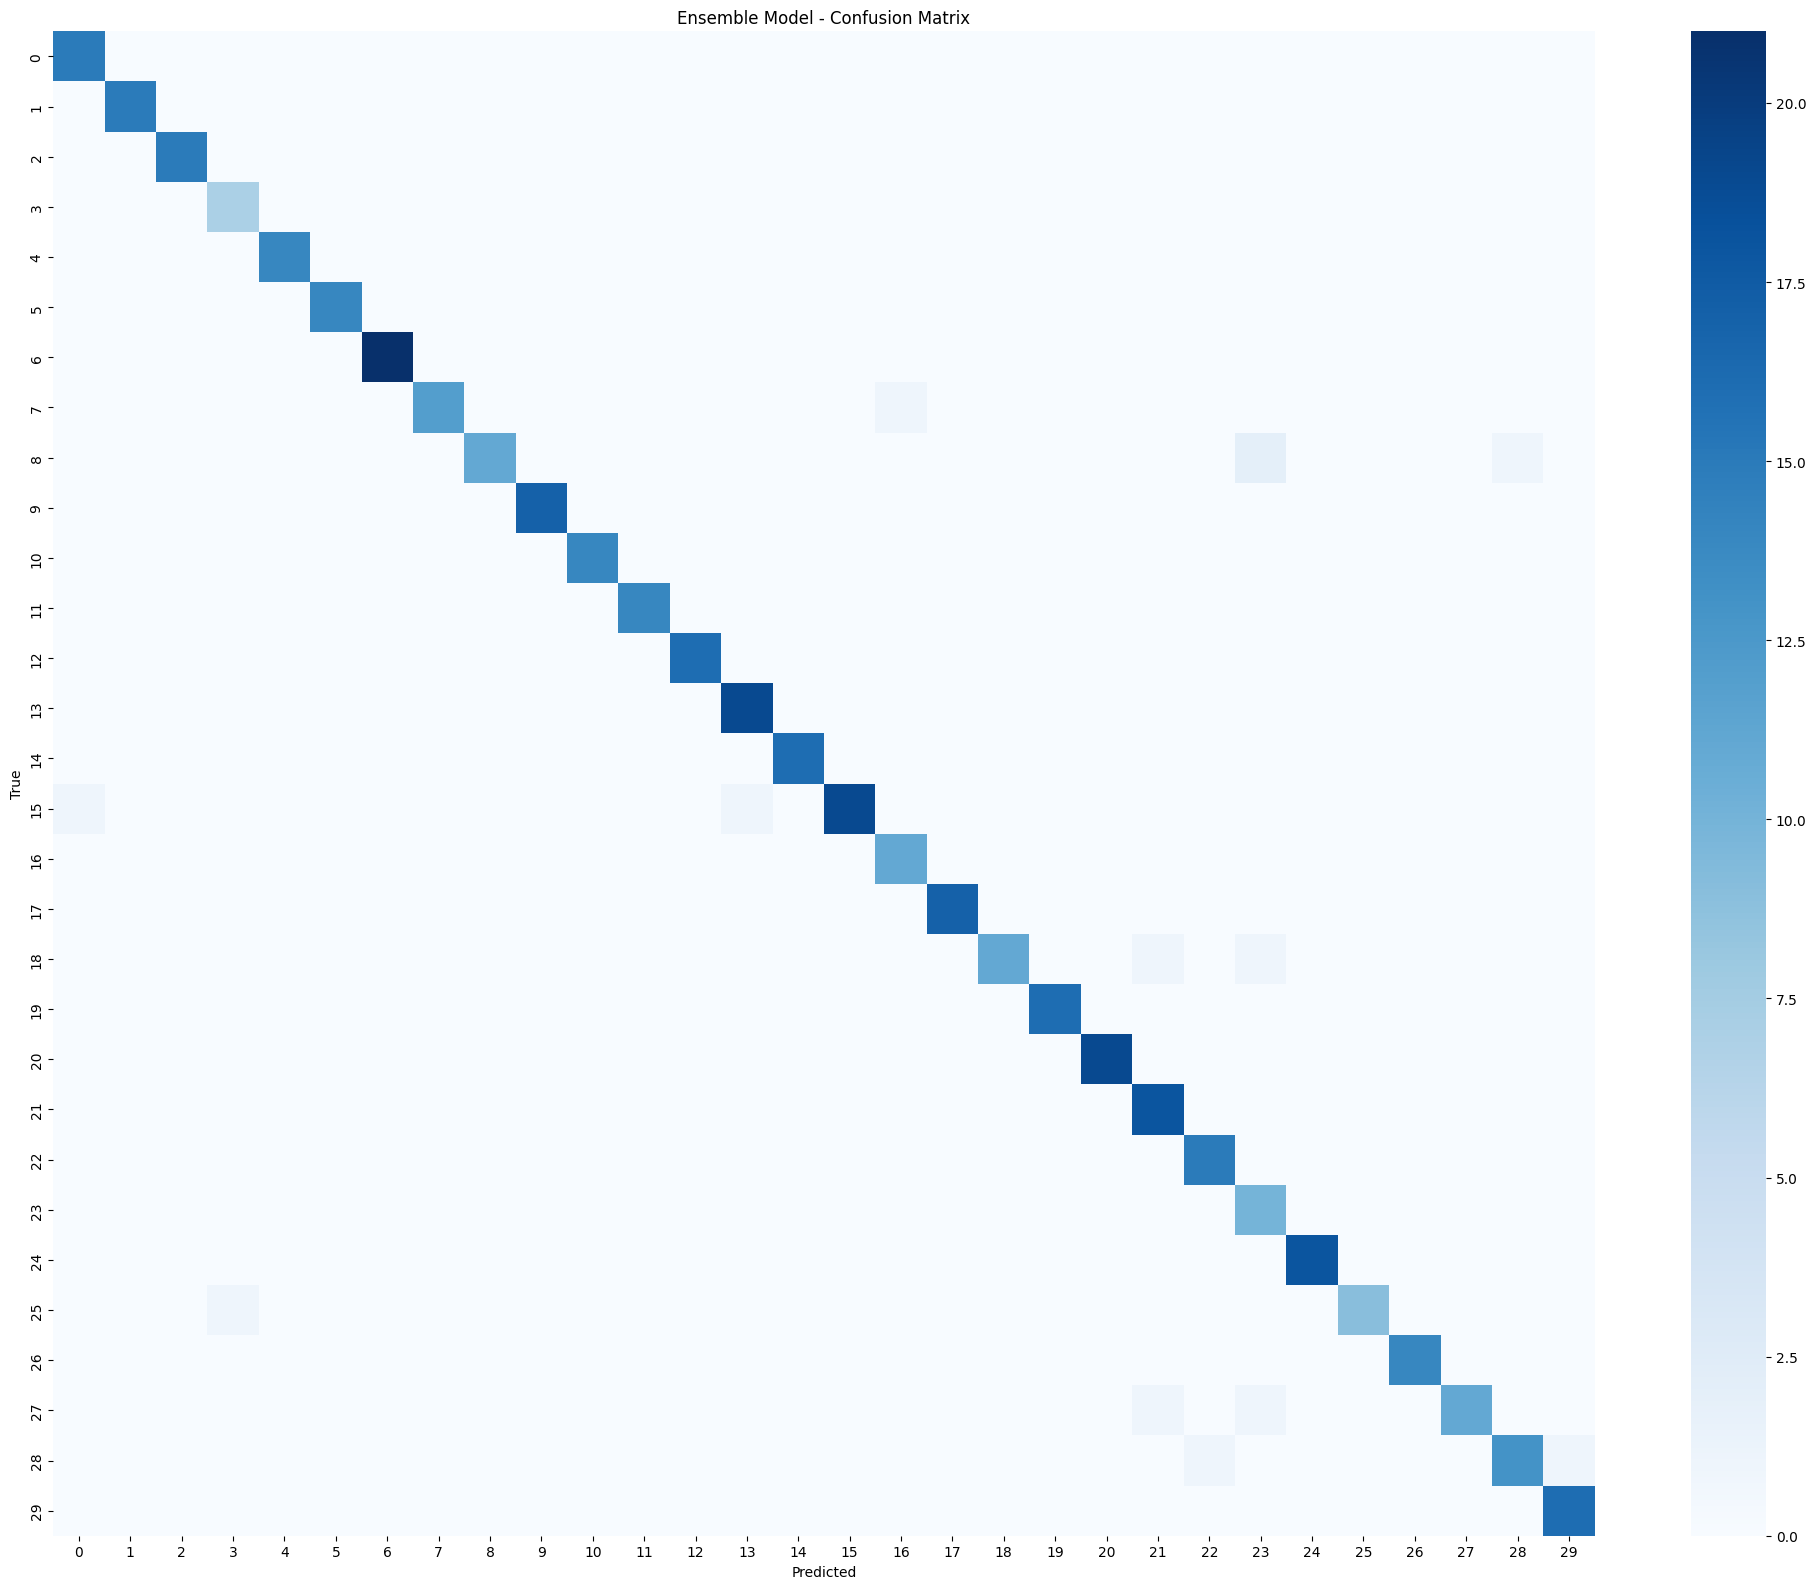


📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL
              precision    recall  f1-score   support

           0      0.938     1.000     0.968        15
           1      1.000     1.000     1.000        15
           2      1.000     1.000     1.000        15
           3      0.875     1.000     0.933         7
           4      1.000     1.000     1.000        14
           5      1.000     1.000     1.000        14
           6      1.000     1.000     1.000        21
           7      1.000     0.923     0.960        13
           8      1.000     0.786     0.880        14
           9      1.000     1.000     1.000        17
          10      1.000     1.000     1.000        14
          11      1.000     1.000     1.000        14
          12      1.000     1.000     1.000        16
          13      0.950     1.000     0.974        19
          14      1.000     1.000     1.000        16
          15      1.000     0.905     0.950        21
          16      0.917     1.

In [30]:
# ============================================
# CELL 10: Evaluate Ensemble on Test Set
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_ensemble(ensemble_model, test_loader):
    """Evaluate ensemble model on test set"""
    ensemble_model.image_model.eval()

    all_preds        = []
    all_labels       = []
    image_only_preds = []
    rf_only_preds    = []

    with torch.no_grad():
        for images, numerical_feats, labels in tqdm(test_loader, desc="Evaluating"):
            images          = images.to(config.DEVICE)
            numerical_feats = numerical_feats.to(config.DEVICE).float()

            # ---- Ensemble prediction ----
            outputs = ensemble_model(images, numerical_feats)
            preds   = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor)
                              else labels)

            # ---- Image-only prediction ----
            img_out   = ensemble_model.image_model(images)
            img_preds = torch.argmax(img_out, dim=1)
            image_only_preds.extend(img_preds.cpu().numpy())

            # ---- RF-only prediction ----
            rf_proba    = ensemble_model.rf_model.predict_proba_tensor(
                numerical_feats, device=images.device
            )
            rf_pred_cls = torch.argmax(rf_proba, dim=1)
            rf_only_preds.extend(rf_pred_cls.cpu().numpy())

    all_preds        = np.array(all_preds)
    all_labels       = np.array(all_labels)
    image_only_preds = np.array(image_only_preds)
    rf_only_preds    = np.array(rf_only_preds)

    ensemble_acc = (all_preds        == all_labels).mean() * 100
    image_acc    = (image_only_preds == all_labels).mean() * 100
    rf_acc       = (rf_only_preds    == all_labels).mean() * 100

    print(f"\n{'='*60}")
    print(f"📊 TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Ensemble Model (Image={config.IMAGE_WEIGHT}, RF={config.NUMERICAL_WEIGHT}): "
          f"{ensemble_acc:.2f}%")
    print(f"\nIndividual Models:")


    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title('Ensemble Model - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_confusion_matrix.png'))
    plt.show()

    print("\n" + "="*80)
    print("📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL")
    print("="*80)
    print(classification_report(all_labels, all_preds, digits=3))

    # Per-class accuracy
    cm_matrix     = confusion_matrix(all_labels, all_preds)
    per_class_acc = cm_matrix.diagonal() / cm_matrix.sum(axis=1)
    print("\n" + "="*60)
    print("📊 PER-CLASS ACCURACY")
    print("="*60)
    for i, acc in enumerate(per_class_acc):
        print(f"   Class {i:2d}: {acc:.4f} ({acc*100:.2f}%)")

    return ensemble_acc, image_acc, rf_acc

ensemble_acc, image_acc, rf_acc = evaluate_ensemble(ensemble_model, test_loader)
